To Do: Implementation – KNN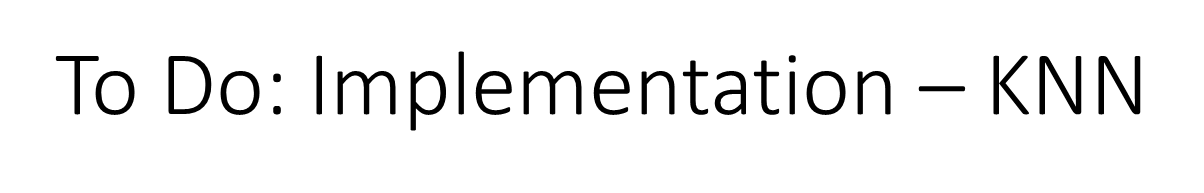

Accuracy: 1.0


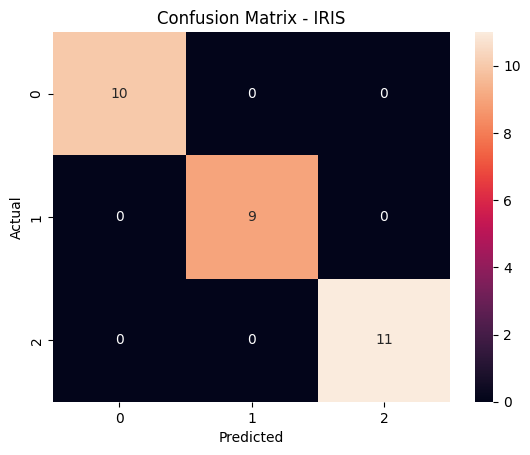


Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [17]:
''' Build a KNN classifier to classify IRIS flower dataset. Choose appropriate k value and predict the score,
display confusion matrix and classification report. Use 80% of data for training and 20% for testing. Display 
accuracy score and confusion matrix of the trained model on test data.
'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Load dataset
data = pd.read_csv("iris (1).csv")

# Features and target
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Split dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Euclidean Distance
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

# Manual KNN Function
def knn_predict(X_train, y_train, test_point, k):
    distances = []

    for i in range(len(X_train)):
        dist = euclidean_distance(test_point, X_train[i])
        distances.append((dist, y_train[i]))

    distances.sort(key=lambda x: x[0])
    neighbors = [distances[i][1] for i in range(k)]

    return Counter(neighbors).most_common(1)[0][0]

# Choose k
k = 5

# Predictions
predictions = []
for test_point in X_test:
    predictions.append(knn_predict(X_train, y_train, test_point, k))

# Accuracy
print("Accuracy:", accuracy_score(y_test, predictions))

# Confusion Matrix
cm = confusion_matrix(y_test, predictions)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - IRIS")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, predictions))

Accuracy: 0.6883116883116883


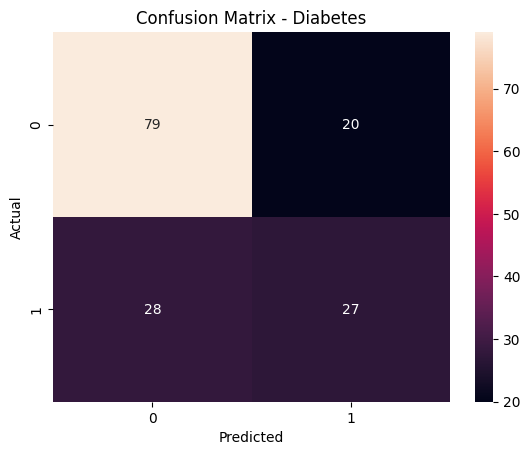

In [6]:
''' Build a KNN classifier to classify diabetes dataset. Choose k value and perform feature scaling. Use 80% 
of data for training and 20% for testing. Display accuracy score and confusion matrix of the trained model on test data.
'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score

# Load dataset
data = pd.read_csv("diabetes.csv")

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Feature Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Euclidean Distance
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

# KNN Function
def knn_predict(X_train, y_train, test_point, k):
    distances = []

    for i in range(len(X_train)):
        dist = euclidean_distance(test_point, X_train[i])
        distances.append((dist, y_train[i]))

    distances.sort(key=lambda x: x[0])
    neighbors = [distances[i][1] for i in range(k)]

    return Counter(neighbors).most_common(1)[0][0]

k = 5

predictions = []
for test_point in X_test:
    predictions.append(knn_predict(X_train, y_train, test_point, k))

print("Accuracy:", accuracy_score(y_test, predictions))

# Confusion Matrix Plot
cm = confusion_matrix(y_test, predictions)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Diabetes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Best K: 5
Best Accuracy: 0.9180327868852459


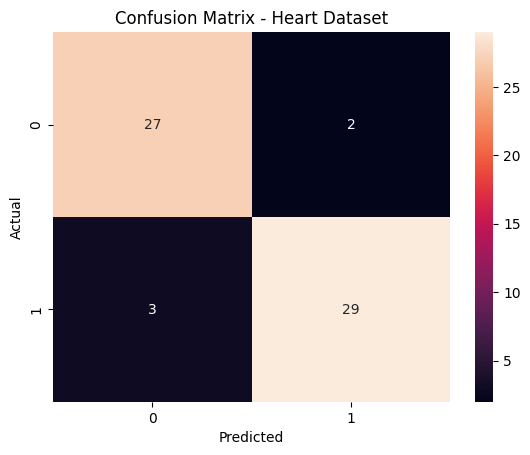


Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.93      0.92        29
           1       0.94      0.91      0.92        32

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61



In [7]:
''' 1) Classify the target using KNN classifier. You can use different values for k neighbors and need to figure out 
a value of K that gives you a maximum score. 2) Plot confusion matrix. 3) Plot classification report
'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
data = pd.read_csv("heart.csv")

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Feature Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Euclidean Distance
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

# KNN Function
def knn_predict(X_train, y_train, test_point, k):
    distances = []

    for i in range(len(X_train)):
        dist = euclidean_distance(test_point, X_train[i])
        distances.append((dist, y_train[i]))

    distances.sort(key=lambda x: x[0])
    neighbors = [distances[i][1] for i in range(k)]

    return Counter(neighbors).most_common(1)[0][0]

# Find Best K
best_k = 1
best_accuracy = 0

for k in range(1, 21):
    predictions = []

    for test_point in X_test:
        predictions.append(knn_predict(X_train, y_train, test_point, k))

    acc = accuracy_score(y_test, predictions)

    if acc > best_accuracy:
        best_accuracy = acc
        best_k = k

print("Best K:", best_k)
print("Best Accuracy:", best_accuracy)

# Final Model
predictions = []
for test_point in X_test:
    predictions.append(knn_predict(X_train, y_train, test_point, best_k))

# Confusion Matrix
cm = confusion_matrix(y_test, predictions)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Heart Dataset")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, predictions))